# Step 1 -- Pure offline validation (sub_001 / sub_002 / sub_003)

Is the animate/inanimate category information decodable at all, under
best-case (offline) processing, for each subject? Reuses the existing
`ModelEvaluator`/`plots.cv_auc` machinery -- no new production code, only
`analysis_lib` additions (`metrics.auc_perm_pvalue`, `plots.plot_tgm_matrix`,
`plots.plot_topomap_grid`).

Per subject x task, this collects:
- `diagonal_auc` / `tgm_matrix` / `peak_auc` / `peak_timepoint` / `chance_level`
  (from `ModelEvaluator.run_evaluation()`)
- a permutation-test p-value at the peak timepoint (`metrics.auc_perm_pvalue`)
- the spatial pattern topomap (recomputed via `ModelTrainer`, since it isn't
  persisted anywhere)

All outputs (figures, CSV, joblib summary) are written under
`tests/notebooks/analysis/report_assets/step1/` -- nothing outside this
analysis directory is touched.


In [1]:
%load_ext autoreload
%autoreload 2

from analysis_lib import context
REPO_ROOT = context.bootstrap()

from pathlib import Path

import joblib
import matplotlib
matplotlib.use("inline")
# Save every figure with a tight bounding box so titles/suptitles/labels drawn
# near or past the figure edge (e.g. suptitle at y=1.02) aren't cropped in PNGs.
matplotlib.rcParams["savefig.bbox"] = "tight"
matplotlib.rcParams["savefig.pad_inches"] = 0.1
import matplotlib.pyplot as plt
import mne
mne.set_log_level("ERROR")
import numpy as np

from analysis_lib import metrics, plots

## Knobs

The three real subjects to run the CV/permutation/spatial-pattern pipeline
against. Each is a `SessionPaths`-shaped output dir with `epochs/` and
`models/decoder_pipeline.joblib` already populated.


In [2]:
SUBJECTS = ["data/sub_001", "data/sub_002", "data/sub_003"]

ASSETS_DIR = REPO_ROOT / "tests" / "notebooks" / "analysis" / "report_assets" / "step1"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR


WindowsPath('C:/Users/itaip/projects/live-reactivation-decoder/tests/notebooks/analysis/report_assets/step1')

## Load contexts + epochs

`context.load_offline_context` resolves each subject's settings/paths --
**not** `context.load_context`, since that unconditionally loads
`models/decoder_pipeline.joblib` (a real, already-trained decoder) even
though nothing in Step 1 uses it: `ModelEvaluator`, the permutation test, and
`ModelTrainer` all refit a fresh classifier from scratch, from the epochs +
the config's `decoders:` block. `load_offline_context` skips that
requirement entirely, so a subject only needs `experiment_config.yaml` +
`epochs/` to be analyzed here, not a completed Phase 1 training run.

Epochs are loaded once per subject here (same `epochs_dir` glob
`plots.cv_auc` uses internally) so they can be reused for the permutation
test and spatial-pattern recomputation below, instead of re-reading the
`.fif` file three separate times.


In [3]:
import glob


def _load_epochs(ctx):
    epo_fif = sorted(glob.glob(str(ctx.paths.epochs_dir / "*epo.fif")))
    assert epo_fif, f"no epochs .fif under {ctx.paths.epochs_dir}"
    return mne.read_epochs(epo_fif[0], verbose=False)


ctxs = {s: context.load_offline_context(s) for s in SUBJECTS}
epochs_by_subject = {s: _load_epochs(ctxs[s]) for s in SUBJECTS}

# Decoder tasks are identical across subjects (same experiment_config.yaml
# `decoders.tasks` block) -- read once, no hardcoding.
TASK_NAMES = [t["name"] for t in ctxs[SUBJECTS[0]].settings.get_decoder_settings()["tasks"]]
SUBJECT_NAMES = {s: Path(s).name for s in SUBJECTS}
TASK_NAMES


['animate decoder', 'inanimate decoder']

## Cross-validated diagonal AUC + full TGM per subject/task

`plots.cv_auc` runs the real 5-fold `StratifiedKFold` + `GeneralizingEstimator`
CV via `ModelEvaluator.run_evaluation()` and returns `diagonal_auc`,
`tgm_matrix`, `peak_auc`, `peak_timepoint`, `chance_level` per task -- plotting
the diagonal-AUC grid as a side effect (saved here as `cv_auc_<subject>.png`;
`ctx.task_tp` is always `None` for an `OfflineContext`, so only the CV peak is
marked, not a "trained tp" -- there is no frozen decoder here to have one).


running 2-decoder temporal-generalization CV (604 epochs, 121 timepoints)...
  [1/2] animate decoder done
  [2/2] inanimate decoder done


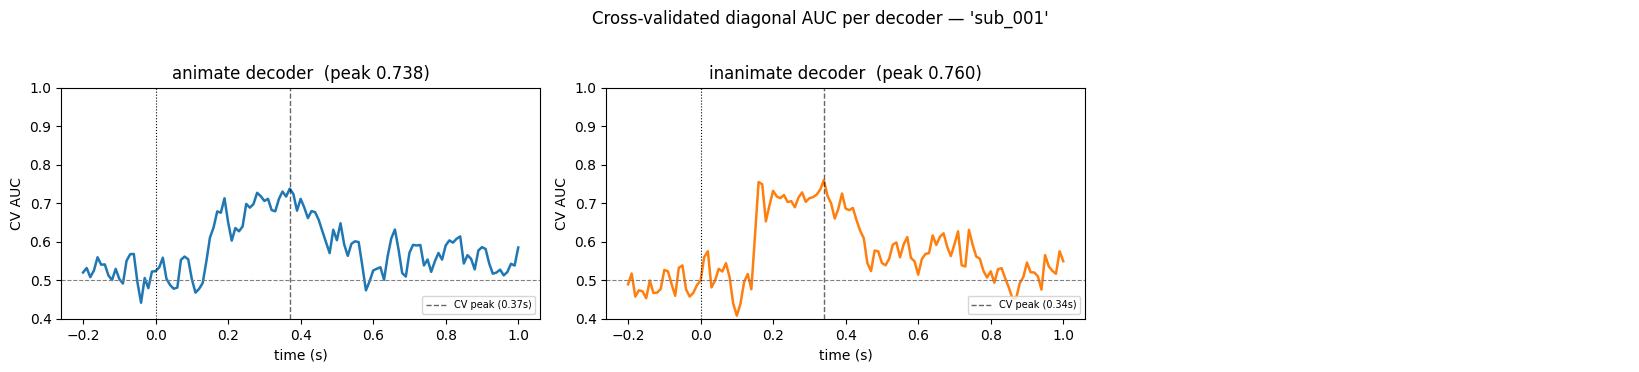

average peak AUC: 0.735 | suggested timepoint: 0.340s
running 2-decoder temporal-generalization CV (604 epochs, 121 timepoints)...
  [1/2] animate decoder done
  [2/2] inanimate decoder done


<Figure size 640x480 with 0 Axes>

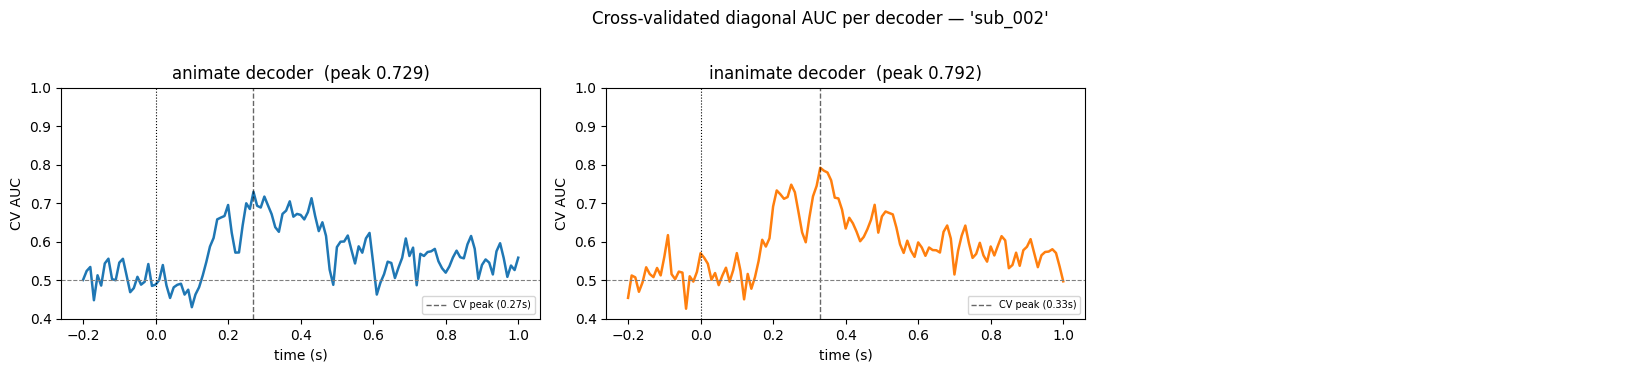

average peak AUC: 0.726 | suggested timepoint: 0.350s
running 2-decoder temporal-generalization CV (604 epochs, 121 timepoints)...
  [1/2] animate decoder done
  [2/2] inanimate decoder done


<Figure size 640x480 with 0 Axes>

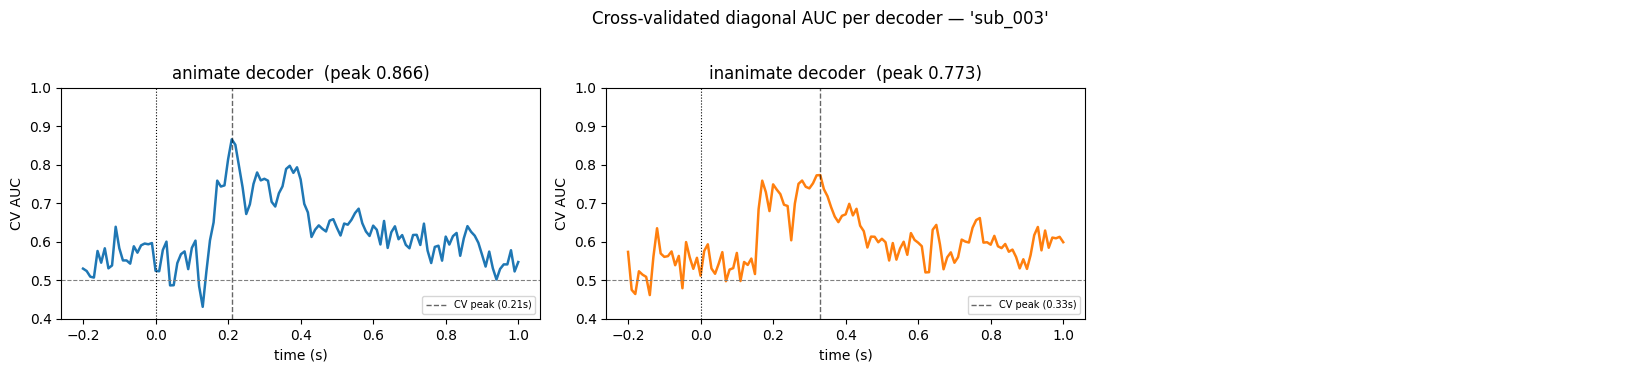

average peak AUC: 0.800 | suggested timepoint: 0.210s


<Figure size 640x480 with 0 Axes>

In [4]:
eval_results = {}
for s in SUBJECTS:
    eval_results[s] = plots.cv_auc(ctxs[s])
    plt.gcf().savefig(ASSETS_DIR / f"cv_auc_{SUBJECT_NAMES[s]}.png", dpi=150, bbox_inches="tight")

## Permutation-test significance at each decoder's peak timepoint

No existing helper tests CV-AUC significance (`metrics.perm_band` permutes
probability-stream means, not AUC), so this uses the new
`metrics.auc_perm_pvalue` -- single-timepoint (the CV-established peak), cheap
enough to refit under many label shuffles *in principle* -- but permuted
(near-chance) labels can take a classifier meaningfully longer to converge
than the real, separable labels, so runtime isn't just "N times the real
fit." `on_progress` prints every `PRINT_EVERY` permutations with elapsed time
and a rough ETA, so a slow run is visibly progressing rather than silent.

**If you haven't run this before, sanity-check the speed first**: set
`N_PERM = 20` below, confirm one `(subject, task)` finishes in a reasonable
time and look at the printed rate, *then* bump back to 1000 for the real run.


In [5]:
import time

N_PERM = 1000
PRINT_EVERY = 25
perm_results = {}  # {(subject, task): (observed_auc, p_value)}

for s in SUBJECTS:
    settings = ctxs[s].settings.get_decoder_settings()
    epochs = epochs_by_subject[s]
    for task in TASK_NAMES:
        peak_tp = eval_results[s]["tasks"][task]["peak_timepoint"]
        print(f"{SUBJECT_NAMES[s]} | {task}: running {N_PERM} permutations @ {peak_tp:+.2f}s ...")
        t0 = time.time()

        def _on_progress(done, total, _t0=t0):
            if done % PRINT_EVERY != 0 and done != total:
                return
            elapsed = time.time() - _t0
            rate = done / elapsed if elapsed > 0 else 0.0
            eta = (total - done) / rate if rate > 0 else float("nan")
            print(f"  [{done}/{total}] {elapsed:5.1f}s elapsed, ~{eta:5.1f}s remaining "
                  f"({rate:.2f} perm/s)")

        observed, _null, p_value = metrics.auc_perm_pvalue(
            epochs, settings, task, peak_tp, n_perm=N_PERM, rng=np.random.default_rng(0),
            on_progress=_on_progress)
        perm_results[(s, task)] = (observed, p_value)
        print(f"{SUBJECT_NAMES[s]:>10s} | {task:<18s}: AUC={observed:.3f} @ {peak_tp:+.2f}s, "
              f"p={p_value:.4f} ({time.time() - t0:.1f}s total)")


sub_001 | animate decoder: running 1000 permutations @ +0.37s ...
  [25/1000] 132.1s elapsed, ~5150.7s remaining (0.19 perm/s)
  [50/1000] 266.8s elapsed, ~5068.5s remaining (0.19 perm/s)
  [75/1000] 369.2s elapsed, ~4552.9s remaining (0.20 perm/s)
  [100/1000] 488.5s elapsed, ~4396.4s remaining (0.20 perm/s)
  [125/1000] 614.5s elapsed, ~4301.4s remaining (0.20 perm/s)
  [150/1000] 744.7s elapsed, ~4219.7s remaining (0.20 perm/s)
  [175/1000] 892.1s elapsed, ~4205.5s remaining (0.20 perm/s)
  [200/1000] 1040.3s elapsed, ~4161.2s remaining (0.19 perm/s)
  [225/1000] 1174.7s elapsed, ~4046.2s remaining (0.19 perm/s)
  [250/1000] 1302.7s elapsed, ~3908.2s remaining (0.19 perm/s)
  [275/1000] 1414.6s elapsed, ~3729.5s remaining (0.19 perm/s)
  [300/1000] 1523.2s elapsed, ~3554.1s remaining (0.20 perm/s)
  [325/1000] 1677.5s elapsed, ~3484.1s remaining (0.19 perm/s)
  [350/1000] 1794.4s elapsed, ~3332.4s remaining (0.20 perm/s)
  [375/1000] 1926.5s elapsed, ~3210.9s remaining (0.19 perm/s)

## Spatial patterns (Haufe activation patterns)

Not persisted anywhere (`decoder_pipeline.joblib` doesn't carry them), so
recomputed at analysis time via `ModelTrainer.run_training`, at each task's
own CV peak timepoint -- same pattern already used ad hoc in
`live_inference_epoched.ipynb`.


In [6]:
from backend.offline_phase.trainer import ModelTrainer

spatial_patterns_by_subject = {}
mne_info_by_subject = {}
for s in SUBJECTS:
    settings = ctxs[s].settings.get_decoder_settings()
    timepoints = {task: eval_results[s]["tasks"][task]["peak_timepoint"] for task in TASK_NAMES}
    training = ModelTrainer(epochs_by_subject[s], settings).run_training(timepoints)
    spatial_patterns_by_subject[s] = training["spatial_patterns"]
    mne_info_by_subject[s] = training["mne_info"]


## Figures: TGM heatmaps + spatial-pattern topomaps

One TGM heatmap per subject x task, and one topomap grid per subject (both
decoders side by side). Saved as PNGs under `report_assets/step1/`.


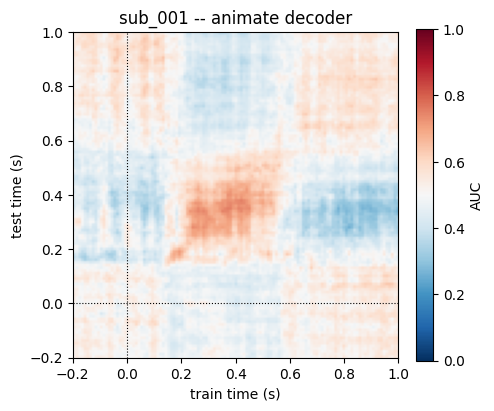

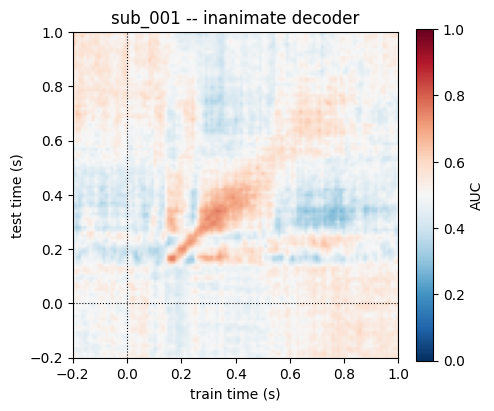

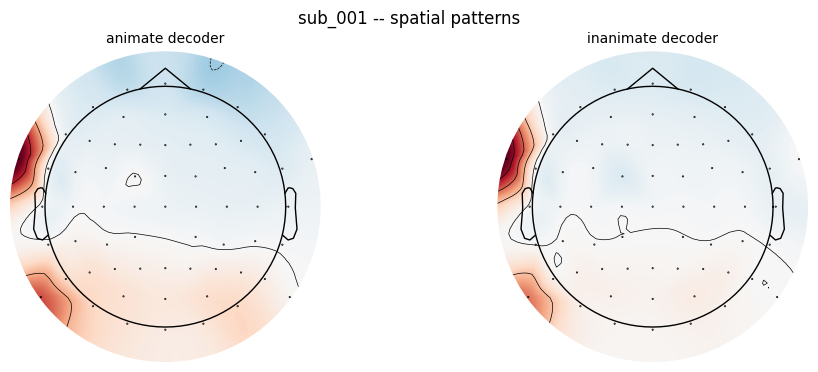

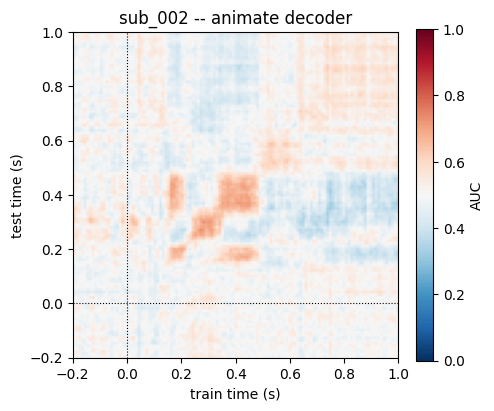

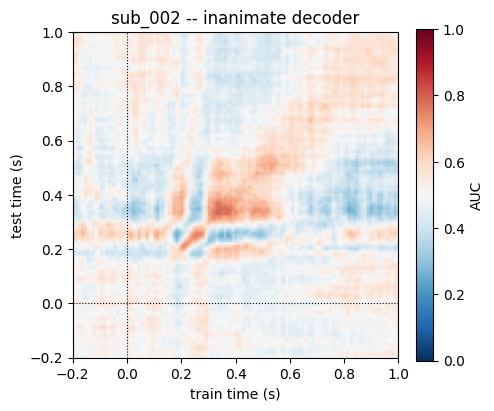

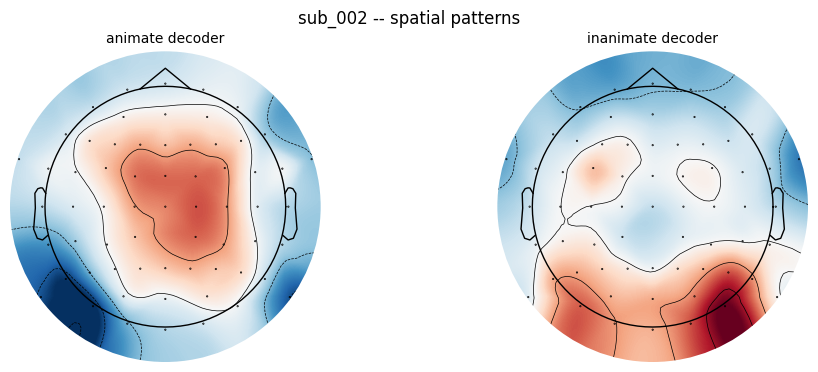

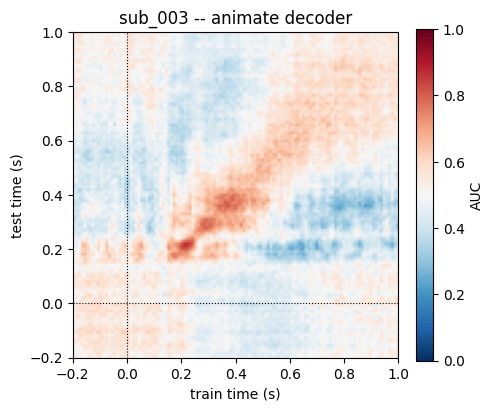

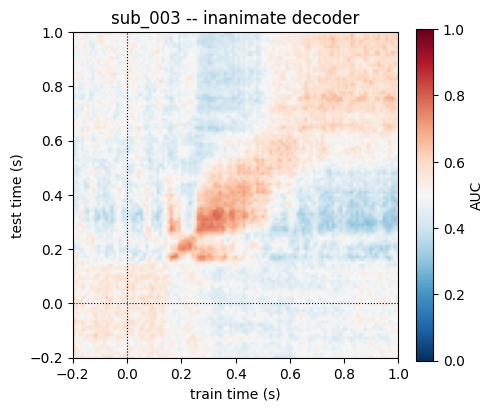

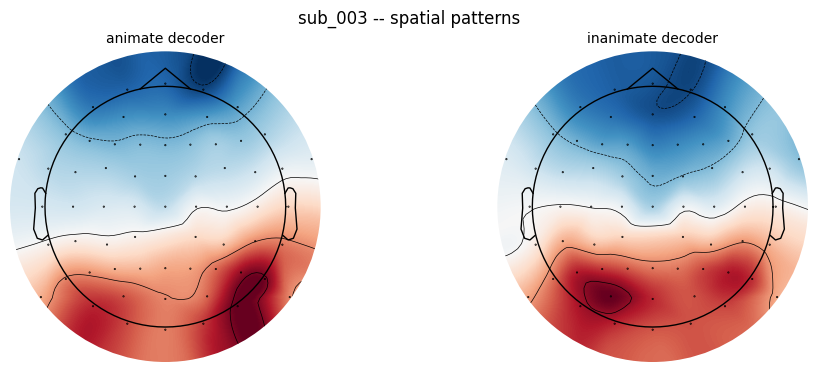

In [7]:
for s in SUBJECTS:
    name = SUBJECT_NAMES[s]
    times = eval_results[s]["times"]
    for task in TASK_NAMES:
        tgm = eval_results[s]["tasks"][task]["tgm_matrix"]
        fig, ax = plt.subplots(figsize=(5, 4.5))
        im = plots.plot_tgm_matrix(tgm, times, f"{name} -- {task}", ax=ax)
        fig.colorbar(im, ax=ax, fraction=0.046, label="AUC")
        plt.tight_layout()
        fig.savefig(ASSETS_DIR / f"tgm_{name}_{task.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

    fig = plots.plot_topomap_grid(spatial_patterns_by_subject[s], mne_info_by_subject[s])
    fig.suptitle(f"{name} -- spatial patterns", y=1.02)
    fig.savefig(ASSETS_DIR / f"topomap_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Per-subject results table

One row per subject x task: `peak_auc`, `peak_timepoint`, `chance_level`, and
the permutation `p_value`. Saved as `step1_results.csv`.


In [8]:
import csv

FIELDS = ["subject", "task", "peak_auc", "peak_timepoint", "chance_level", "p_value"]
rows = []
for s in SUBJECTS:
    name = SUBJECT_NAMES[s]
    for task in TASK_NAMES:
        td = eval_results[s]["tasks"][task]
        observed, p_value = perm_results[(s, task)]
        rows.append({
            "subject": name, "task": task,
            "peak_auc": td["peak_auc"], "peak_timepoint": td["peak_timepoint"],
            "chance_level": td["chance_level"], "p_value": p_value,
        })

with open(ASSETS_DIR / "step1_results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDS)
    writer.writeheader()
    writer.writerows(rows)

w = 12
header = "subject".ljust(14) + "task".ljust(20) + "".join(
    h.rjust(w) for h in ("peak_auc", "peak_tp", "chance", "p_value"))
print(header); print("-" * len(header))
for r in rows:
    print(r["subject"].ljust(14) + r["task"].ljust(20)
          + f"{r['peak_auc']:.3f}".rjust(w) + f"{r['peak_timepoint']:.2f}".rjust(w)
          + f"{r['chance_level']:.3f}".rjust(w) + f"{r['p_value']:.4f}".rjust(w))


subject       task                    peak_auc     peak_tp      chance     p_value
----------------------------------------------------------------------------------
sub_001       animate decoder            0.738        0.37       0.500      0.0010
sub_001       inanimate decoder          0.760        0.34       0.500      0.0010
sub_002       animate decoder            0.729        0.27       0.500      0.0010
sub_002       inanimate decoder          0.792        0.33       0.500      0.0010
sub_003       animate decoder            0.866        0.21       0.500      0.0010
sub_003       inanimate decoder          0.773        0.33       0.500      0.0010


## Cross-subject descriptive aggregation

With n=3, this is deliberately descriptive, not a powered group test: thin
per-subject diagonal-AUC lines + a bold grand mean, framed as "consistency
across subjects."


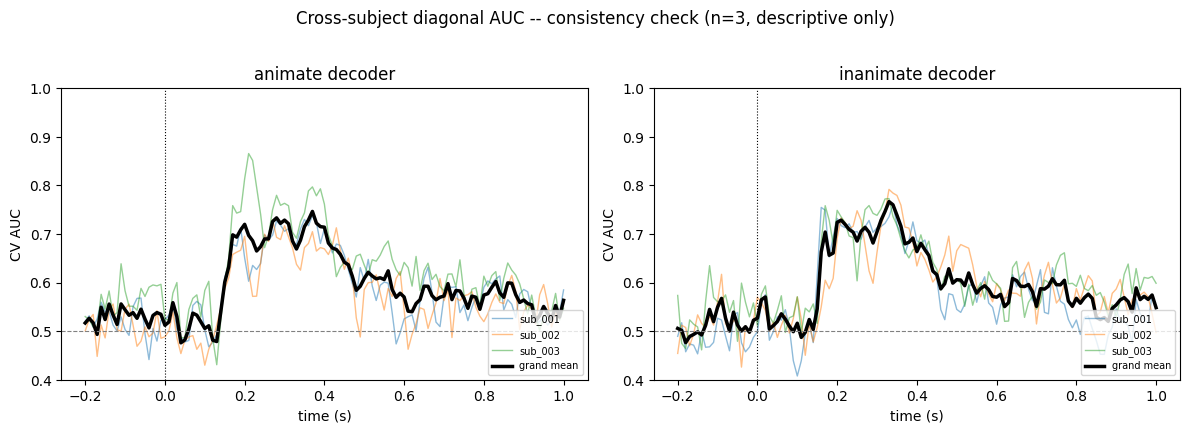

In [9]:
SUBJECT_COLORS = {s: plt.cm.tab10(i % 10) for i, s in enumerate(SUBJECTS)}

fig, axes = plt.subplots(1, len(TASK_NAMES), figsize=(6 * len(TASK_NAMES), 4.2), squeeze=False)
times = eval_results[SUBJECTS[0]]["times"]
for idx, task in enumerate(TASK_NAMES):
    ax = axes[0][idx]
    curves = []
    for s in SUBJECTS:
        curve = eval_results[s]["tasks"][task]["diagonal_auc"]
        curves.append(curve)
        ax.plot(times, curve, color=SUBJECT_COLORS[s], lw=1.0, alpha=0.5, label=SUBJECT_NAMES[s])
    mean_curve = np.mean(curves, axis=0)
    ax.plot(times, mean_curve, color="black", lw=2.5, label="grand mean")
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.set(title=task, ylim=(0.4, 1.0), xlabel="time (s)", ylabel="CV AUC")
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("Cross-subject diagonal AUC -- consistency check (n=3, descriptive only)", y=1.02)
plt.tight_layout()
fig.savefig(ASSETS_DIR / "grand_average_diagonal_auc.png", dpi=150, bbox_inches="tight")
plt.show()

## Save summary

Bundles everything (curves, TGMs, spatial patterns, permutation results, the
results table) into one joblib file for reuse when writing the report.


In [10]:
summary = {
    "subjects": SUBJECTS,
    "tasks": TASK_NAMES,
    "eval_results": eval_results,
    "perm_results": perm_results,
    "spatial_patterns": spatial_patterns_by_subject,
    "results_table": rows,
}
out_path = ASSETS_DIR / "step1_summary.joblib"
joblib.dump(summary, out_path)
print(f"saved to {out_path}")


saved to C:\Users\itaip\projects\live-reactivation-decoder\tests\notebooks\analysis\report_assets\step1\step1_summary.joblib
